# ACO / ACO + refinement / KMeans comparison with the new optimizer architecture

This notebook tests the new refactor:

- `AntClusteringOptimizer` is the shared optimization engine.
- `construct_aco_solution` and `construct_aco_refinement_solution` are the only algorithm-specific construction strategies.
- `fitness_weighted_sum` is shared.
- `update_pheromone_all_ants` / `update_pheromone_best_ant` are shared pheromone update functions.
- preprocessing and plotting are reused from the shared modules.

The goal is to compare ACO variants while keeping fitness, pheromone update, preprocessing, and plotting consistent.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from moduli.preprocessing import (
    build_raw_features,
    build_koppen_features,
    build_temp_rain_pca_features,
    prepare_model_data,
)

from moduli.ant_clustering_optimizer import AntClusteringOptimizer
from moduli.construction_strategies import (
    construct_aco_solution,
    construct_aco_refinement_solution,
    construct_graph_aco_solution,
    construct_multicolony_solution
)
from moduli.heuristics import (
    centroid_heuristic,
    graph_heuristic,
    spatial_heuristic,
    graph_cohesion_heuristic
)
from moduli.fitness_functions import fitness_weighted_sum
from moduli.pheromone_updates import (
    initialize_node_cluster_pheromone,
    update_pheromone_all_ants,
    update_pheromone_best_ant,
    update_pheromone_quality_weighted,
)
from moduli.plot_utils import plot_cluster_comparison, plot_single_cluster_map


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

Change these values to compare pixel/superpixel mode and feature representations.


In [6]:
DATA_PATH = "../../df_valid.csv"

# "superpixels" or "pixels"
MODE = "superpixels"

# "koppen", "raw", or "pca_before_superpixels"
FEATURE_MODE = "koppen"

N_CLUSTERS = 5
TARGET_SIZE = 150
K_NEIGHBORS = 16
RANDOM_STATE = 0


## Load data and build features

Feature construction is separate from preprocessing, so the same optimizer setup can be tested with raw, Köppen-like, or PCA features.


In [7]:
df = pd.read_csv(DATA_PATH, index_col=0)

if FEATURE_MODE == "koppen":
    X_features, feature_names = build_koppen_features(df)

elif FEATURE_MODE == "raw":
    X_features, feature_names = build_raw_features(df)

elif FEATURE_MODE == "pca_before_superpixels":
    raw_X, feature_cols = build_raw_features(df)
    temp_cols = [c for c in feature_cols if "temp" in c.lower()]
    rain_cols = [c for c in feature_cols if "padavine" in c.lower()]

    X_features, feature_names, pca_info = build_temp_rain_pca_features(
        df,
        temp_cols=temp_cols,
        rain_cols=rain_cols,
        n_temp=2,
        n_rain=2,
        final_scale=True,
    )

    print("Temperature explained variance:")
    print(pca_info["temp_explained_variance"])
    print("Rainfall explained variance:")
    print(pca_info["rain_explained_variance"])

else:
    raise ValueError("FEATURE_MODE must be 'koppen', 'raw', or 'pca_before_superpixels'.")

print("df shape:", df.shape)
print("X_features shape:", X_features.shape)
print("feature_names:", feature_names)


df shape: (301394, 35)
X_features shape: (301394, 9)
feature_names: ['temp_mean', 'temp_min', 'temp_max', 'temp_range', 'precip_mean', 'precip_min', 'precip_max', 'precip_total', 'precip_range']


## Prepare model data

This creates the common model inputs:

```python
X
neighbors
weights
```

Both ACO variants receive exactly the same inputs.


In [8]:
data = prepare_model_data(
    df=df,
    X_features=X_features,
    feature_names=feature_names,
    mode=MODE,
    target_size=TARGET_SIZE,
    k_neighbors=K_NEIGHBORS,
    scale_final=True,
    random_state=RANDOM_STATE,
)

X = data["X_model"]
neighbors = data["neighbors"]
weights = data["weights"]

df_model = data["df"]
node_col = data["node_col"]

print("mode:", data["mode"])
print("node_col:", node_col)
print("X shape:", X.shape)
print("neighbors shape:", neighbors.shape)
print("weights shape:", weights.shape)


mode: superpixels
node_col: superpixel_compact
X shape: (2009, 9)
neighbors shape: (2009, 16)
weights shape: (2009,)


## Shared optimizer settings

These are shared by both ACO variants.

The important thing is that both use the same:

```python
fitness_fn=fitness_weighted_sum
pheromone_update_fn=...
pheromone_init_fn=...
```

Only the construction strategy differs.


In [12]:
COMMON_FITNESS_KWARGS = {
    "w_compactness": 0.7,
    "w_spatial": 0.3,
    "spatial_symmetric": False,
}

COMMON_PHEROMONE_INIT_KWARGS = {
    "initial_value": 1.0,
    "normalize_rows": True,
}

COMMON_PHEROMONE_UPDATE_KWARGS = {
    "clip_min": 1e-6,
    "clip_max": 1e6,
    "normalize_rows": True,
}

## KMeans baseline

KMeans is fitted on the same `X`.

Its centroids are used as optional base centroids for ACO + refinement construction.


In [11]:
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    n_init=10,
    random_state=RANDOM_STATE,
).fit(X)

base_centroids = kmeans.cluster_centers_

kmeans_fitness, kmeans_terms = fitness_weighted_sum(
    X=X,
    labels=kmeans.labels_,
    centroids=base_centroids,
    weights=weights,
    neighbors=neighbors,
    **COMMON_FITNESS_KWARGS,
)

print(kmeans_fitness)
print(kmeans_terms)

0.2376042185340272
{'compactness': 0.19379977603275308, 'spatial': 0.3398145843703335}


## ACO via `AntClusteringOptimizer`

ACO-specific behavior is only in `construct_aco_solution`.


In [13]:
# Choose one:
# ACO_PHEROMONE_UPDATE_FN = update_pheromone_all_ants
ACO_PHEROMONE_UPDATE_FN = update_pheromone_best_ant
# ACO_PHEROMONE_UPDATE_FN = update_pheromone_quality_weighted

aco = AntClusteringOptimizer(
    n_clusters=N_CLUSTERS,
    n_ants=15,
    n_iterations=20,

    construct_solution_fn=construct_aco_solution,
    construct_kwargs={
        "alpha": 1,
        "beta_feature": 3,
        "centroid": True
    },

    fitness_fn=fitness_weighted_sum,
    fitness_kwargs=COMMON_FITNESS_KWARGS,

    pheromone_init_fn=initialize_node_cluster_pheromone,
    pheromone_init_kwargs=COMMON_PHEROMONE_INIT_KWARGS,

    pheromone_update_fn=ACO_PHEROMONE_UPDATE_FN,
    pheromone_update_kwargs=COMMON_PHEROMONE_UPDATE_KWARGS,

    evaporation=0.1,
    q=0.05,
    random_state=RANDOM_STATE,
    verbose=True,
    pheromone_update_batch_size=None
)

aco.fit(X, neighbors, weights=weights)


Iter 1/20 | iter_best=0.2701 | iter_mean=0.2857 | iter_std=0.0115 | global_best=0.2701 | compactness=0.2271 | spatial=0.3704 | pheromone_min=1.6588e-01 | pheromone_max=3.3647e-01
Iter 2/20 | iter_best=0.2614 | iter_mean=0.2838 | iter_std=0.0226 | global_best=0.2614 | compactness=0.2286 | spatial=0.3379 | pheromone_min=1.3681e-01 | pheromone_max=4.5277e-01
Iter 3/20 | iter_best=0.2624 | iter_mean=0.2848 | iter_std=0.0140 | global_best=0.2614 | compactness=0.2262 | spatial=0.3469 | pheromone_min=1.1290e-01 | pheromone_max=5.4839e-01
Iter 4/20 | iter_best=0.2571 | iter_mean=0.2757 | iter_std=0.0166 | global_best=0.2571 | compactness=0.2364 | spatial=0.3054 | pheromone_min=9.2840e-02 | pheromone_max=6.2864e-01
Iter 5/20 | iter_best=0.2598 | iter_mean=0.2852 | iter_std=0.0169 | global_best=0.2571 | compactness=0.2201 | spatial=0.3524 | pheromone_min=7.6484e-02 | pheromone_max=6.9406e-01
Iter 6/20 | iter_best=0.2625 | iter_mean=0.2898 | iter_std=0.0149 | global_best=0.2571 | compactness=0.23

## ACO + refinement via `AntClusteringOptimizer`

ACO + refinement-specific behavior is only in `construct_aco_refinement_solution`.


In [15]:
# Choose one:
ACO_REFINEMENT_PHEROMONE_UPDATE_FN = update_pheromone_all_ants
# ACO_REFINEMENT_PHEROMONE_UPDATE_FN = update_pheromone_best_ant
# ACO_REFINEMENT_PHEROMONE_UPDATE_FN = update_pheromone_quality_weighted

aco_refinement = AntClusteringOptimizer(
    n_clusters=N_CLUSTERS,
    n_ants=15,
    n_iterations=20,

    construct_solution_fn=construct_aco_refinement_solution,
    construct_kwargs={
        "alpha": 0.75,
        "beta_feature": 1,
        "refinement_steps": 3,
        "centroid": True
    },

    fitness_fn=fitness_weighted_sum,
    fitness_kwargs=COMMON_FITNESS_KWARGS,

    pheromone_init_fn=initialize_node_cluster_pheromone,
    pheromone_init_kwargs=COMMON_PHEROMONE_INIT_KWARGS,

    pheromone_update_fn=ACO_REFINEMENT_PHEROMONE_UPDATE_FN,
    pheromone_update_kwargs=COMMON_PHEROMONE_UPDATE_KWARGS,

    evaporation=0.1,
    q=0.05,
    random_state=RANDOM_STATE,
    verbose=True,
    pheromone_update_batch_size=5
)

aco_refinement.fit(X, neighbors, weights=weights)


Iter 1/20 | iter_best=0.9166 | iter_mean=0.9279 | iter_std=0.0051 | global_best=0.9166 | compactness=0.9703 | spatial=0.7913 | pheromone_min=9.1164e-02 | pheromone_max=5.1879e-01
Iter 2/20 | iter_best=0.8553 | iter_mean=0.8966 | iter_std=0.0213 | global_best=0.8553 | compactness=0.8937 | spatial=0.7659 | pheromone_min=4.0553e-02 | pheromone_max=6.5800e-01
Iter 3/20 | iter_best=0.6568 | iter_mean=0.7516 | iter_std=0.0635 | global_best=0.6568 | compactness=0.6695 | spatial=0.6273 | pheromone_min=1.5703e-02 | pheromone_max=8.2862e-01
Iter 4/20 | iter_best=0.4517 | iter_mean=0.5198 | iter_std=0.0498 | global_best=0.4517 | compactness=0.4306 | spatial=0.5011 | pheromone_min=4.3127e-03 | pheromone_max=9.5082e-01
Iter 5/20 | iter_best=0.3653 | iter_mean=0.3936 | iter_std=0.0207 | global_best=0.3653 | compactness=0.3369 | spatial=0.4315 | pheromone_min=8.6645e-04 | pheromone_max=9.8830e-01
Iter 6/20 | iter_best=0.3093 | iter_mean=0.3329 | iter_std=0.0145 | global_best=0.3093 | compactness=0.27

## Graph ACO via `AntClusteringOptimizer`

Graph ACO-specific behavior is only in `construct_graph_aco_solution`.


In [ ]:
graph_aco = AntClusteringOptimizer(
    n_clusters=N_CLUSTERS,
    n_ants=15,
    n_iterations=20,

    construct_solution_fn=construct_graph_aco_solution,
    construct_kwargs={
        "alpha": 1,
        "beta_graph": 2.5,
    },

    fitness_fn=fitness_weighted_sum,
    fitness_kwargs=COMMON_FITNESS_KWARGS,

    pheromone_init_fn=initialize_node_cluster_pheromone,
    pheromone_init_kwargs=COMMON_PHEROMONE_INIT_KWARGS,

    pheromone_update_fn=PHEROMONE_UPDATE_FN,
    pheromone_update_kwargs=COMMON_PHEROMONE_UPDATE_KWARGS,

    evaporation=0.5,
    q=0.05,
    random_state=RANDOM_STATE,
    verbose=True,
    pheromone_update_batch_size=10
)

graph_aco.fit(X, neighbors, weights=weights)

In [ ]:
n_ants=30
colonies = [
    {
        "name": "graph_cohesion_heuristic",
        "fn": graph_cohesion_heuristic,
        "params": {
            "beta_graph": 2.5,
        },
    },
    # {
    #     "name": "graph",
    #     "fn": graph_heuristic,
    #     "params": {
    #         "beta_graph": 1.5,
    #     },
    # },
    {
        "name": "spatial",
        "fn": spatial_heuristic,
        "params": {
            "beta_spatial": 2.5,
        },
    },
]
multi_type_aco = AntClusteringOptimizer(
    n_clusters=N_CLUSTERS,
    n_ants=n_ants,
    n_iterations=20,

    construct_solution_fn=construct_multicolony_solution,
    construct_kwargs={
        "colony_heuristics": colonies,
        "alpha": 1,
    },

    fitness_fn=fitness_weighted_sum,
    fitness_kwargs=COMMON_FITNESS_KWARGS,

    pheromone_init_fn=initialize_node_cluster_pheromone,
    pheromone_init_kwargs=COMMON_PHEROMONE_INIT_KWARGS,

    pheromone_update_fn=PHEROMONE_UPDATE_FN,
    pheromone_update_kwargs=COMMON_PHEROMONE_UPDATE_KWARGS,

    evaporation=0.005,
    q=0.025,
    random_state=RANDOM_STATE,
    verbose=True,
    pheromone_update_batch_size=5
)

multi_type_aco.fit(X, neighbors, weights=weights)

## Numerical comparison

ARI close to 1 means two labelings are very similar.

Fitness values are now comparable because both ACO variants use the same normalized weighted-sum fitness.


In [38]:
print("ACO best fitness:", aco.best_fitness_)
print("ACO + refinement best fitness:", aco_refinement.best_fitness_)
# print("graph_aco best fitness:", graph_aco.best_fitness_)
# print("graph_aco multi_type_aco fitness:", multi_type_aco.best_fitness_)
print()

print("ARI ACO vs KMeans:", adjusted_rand_score(aco.labels_, kmeans.labels_))
print("ARI ACO + refinement vs KMeans:", adjusted_rand_score(aco_refinement.labels_, kmeans.labels_))
# print("ARI multi_type_aco vs KMeans:", adjusted_rand_score(multi_type_aco.labels_, kmeans.labels_))
# print("ARI graph_aco vs KMeans:", adjusted_rand_score(graph_aco.labels_, kmeans.labels_))
print("ARI ACO vs ACO + refinement:", adjusted_rand_score(aco.labels_, aco_refinement.labels_))
print("ARI Koppen vs KMeans:", adjusted_rand_score(kmeans.labels_, koppen_labels["0"]))
print("ARI KMeans vs KMeans:", adjusted_rand_score(kmeans.labels_, kmeans.labels_))


# print("ARI graph_aco vs ACO + refinement:", adjusted_rand_score(graph_aco.labels_, aco_refinement.labels_))
# print("ARI graph_aco vs ACO:", adjusted_rand_score(aco.labels_, graph_aco.labels_))
# print("ARI multi_type_aco vs ACO + refinement:", adjusted_rand_score(multi_type_aco.labels_, aco_refinement.labels_))
# print("ARI multi_type_aco vs ACO:", adjusted_rand_score(aco.labels_, multi_type_aco.labels_))
# print("ARI multi_type_aco vs graph_aco:", adjusted_rand_score(multi_type_aco.labels_, graph_aco.labels_))
print()

aco_terms = pd.DataFrame(aco.term_history_)
aco_refinement_terms = pd.DataFrame(aco_refinement.term_history_)
# graph_aco_terms = pd.DataFrame(graph_aco.term_history_)
# multi_type_aco_terms = pd.DataFrame(multi_type_aco.term_history_)

display(aco_terms.tail())
display(aco_refinement_terms.tail())
# display(graph_aco_terms.tail())
# display(multi_type_aco_terms.tail())

ACO best fitness: 0.23234209056559446
ACO + refinement best fitness: 0.2532721070024367

ARI ACO vs KMeans: 0.41348076677351986
ARI ACO + refinement vs KMeans: 0.63526086039806
ARI ACO vs ACO + refinement: 0.3765258032447277
ARI Koppen vs KMeans: 0.3557742225409542
ARI KMeans vs KMeans: 1.0



,iteration,iteration_best,global_best,mean,std,pheromone_min,pheromone_max,compactness,spatial
15,16,0.236098,0.236098,0.250034,0.015181,0.008059,0.967763,0.219607,0.274577
16,17,0.235650,0.235650,0.253988,0.023939,0.006522,0.973913,0.209088,0.297629
17,18,0.233474,0.233474,0.240997,0.008887,0.005268,0.978928,0.206605,0.296167
18,19,0.232476,0.232476,0.249882,0.036495,0.004252,0.982992,0.207126,0.291625
19,20,0.232342,0.232342,0.239564,0.006720,0.003431,0.986274,0.206948,0.291594


,iteration,iteration_best,global_best,mean,std,pheromone_min,pheromone_max,compactness,spatial
15,16,0.254415,0.254415,0.255657,0.000850,5.324024e-07,0.999998,0.219108,0.336797
16,17,0.253314,0.253314,0.254842,0.001017,5.316870e-07,0.999998,0.218255,0.335117
17,18,0.253272,0.253272,0.254681,0.001187,5.313484e-07,0.999998,0.219102,0.333001
18,19,0.253542,0.253272,0.254801,0.000910,5.315948e-07,0.999998,0.218049,0.336361
19,20,0.253556,0.253272,0.254413,0.000616,5.307960e-07,0.999998,0.218494,0.335366


In [23]:
koppen_labels = pd.read_csv("../../koppen_labels_aggregated.csv", index_col=0)
koppen_labels

,0
0,1
1,1
2,3
3,3
4,1
...,...
2004,1
2005,1
2006,3
2007,1


In [28]:
koppen_labels["0"]

0       1
1       1
2       3
3       3
4       1
       ..
2004    1
2005    1
2006    3
2007    1
2008    2
Name: 0, Length: 2009, dtype: int64

## Plot ACO / ACO + refinement / KMeans side by side

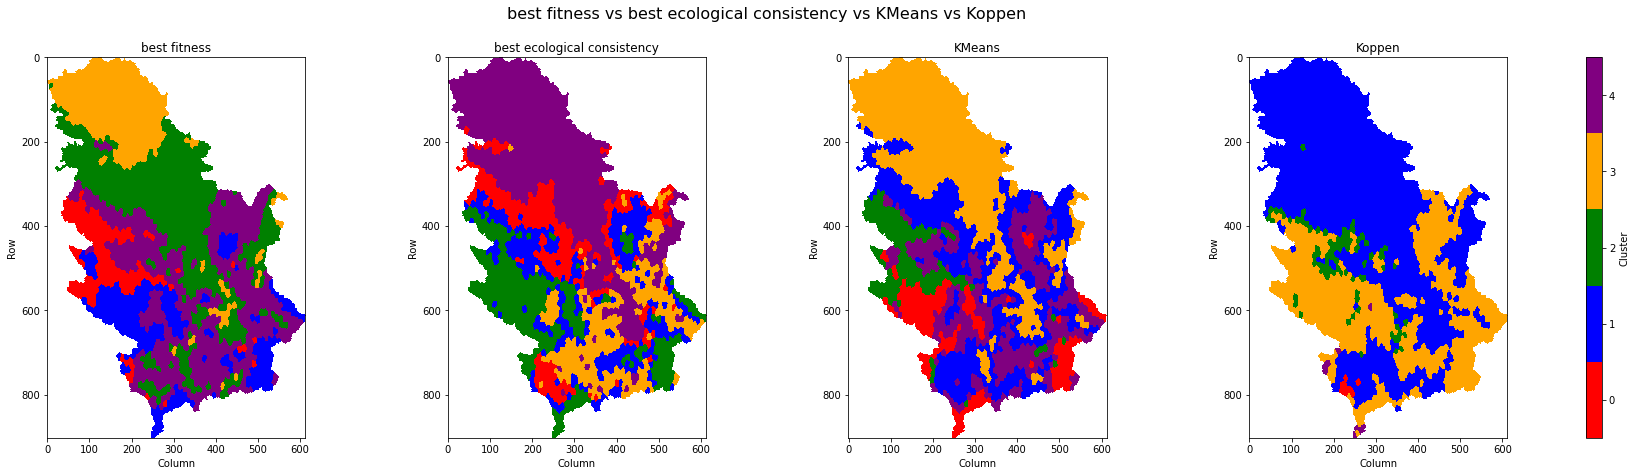

In [34]:
plot_cluster_comparison(
    df=df_model,
    label_dict={
        "best fitness": aco.labels_,
        "best ecological consistency": aco_refinement.labels_,
        "KMeans": kmeans.labels_,
        # "graph": graph_aco.labels_,
        # "multi": multi_type_aco.labels_,
        "Koppen": koppen_labels["0"],
    },
    node_col=node_col,
    n_clusters=N_CLUSTERS,
    title=f"best fitness vs best ecological consistency vs KMeans vs Koppen",
    save_path="../../plot_comparison.png",
)


In [ ]:
import pandas as pd

from moduli.vegetation_eval import (
    load_clc_legend,
    attach_node_labels_to_pixels,
    merge_clusters_with_vegetation,
    add_clc_metadata,
    vegetation_quality_report,
    vegetation_contingency_table,
    plot_landcover_groups,
    plot_cluster_landcover,
)

In [ ]:
VEGETATION_PATH = "../vegetacija.csv"
CLC_LEGEND_PATH = "../Vegetacija/u2018_clc2018_v2020_20u1_raster100m/Legend/CLC2018_CLC2018_V2018_20_QGIS.txt"

vegetation = pd.read_csv(VEGETATION_PATH)
legend = load_clc_legend(CLC_LEGEND_PATH)

vegetation.head()

In [ ]:
method_labels = {
    "ACO": aco.labels_,
    "ACO + refinement": aco_refinement.labels_,
    "graph": graph_aco.labels_,
    "multi": multi_type_aco.labels_,
    "KMeans": kmeans.labels_,
}

vegetation_results = {}
vegetation_summaries = []

for method_name, labels in method_labels.items():
    df_clusters = attach_node_labels_to_pixels(
        df=df_model,
        node_labels=labels,
        node_col=node_col,
        cluster_col="cluster",
    )

    merged = merge_clusters_with_vegetation(
        clusters_df=df_clusters,
        vegetation_df=vegetation,
        cluster_col="cluster",
    )

    merged = add_clc_metadata(
        merged,
        legend=legend,
    )

    report = vegetation_quality_report(
        merged,
        cluster_col="cluster",
        class_col="clc_group",
    )

    vegetation_results[method_name] = {
        "merged": merged,
        "report": report,
    }

    summary = report["overall"].copy()
    summary["method"] = method_name
    vegetation_summaries.append(summary)

veg_comparison = pd.DataFrame(vegetation_summaries)

veg_comparison = veg_comparison[
    [
        "method",
        "weighted_dominant_class_share",
        "weighted_normalized_entropy",
        "weighted_simpson_diversity",
        "mean_dominant_class_share",
        "mean_normalized_entropy",
        "mean_simpson_diversity",
    ]
]

veg_comparison

## Optional: plot one result only

In [ ]:
plot_single_cluster_map(
    df=df_model,
    node_labels=aco_refinement.labels_,
    node_col=node_col,
    n_clusters=N_CLUSTERS,
    title=f"ACO + refinement via AntClusteringOptimizer ({MODE}, {FEATURE_MODE})",
)


## Optional: plot optimization histories

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(aco.history_, label="ACO")
plt.plot(aco_refinement.history_, label="ACO + refinement")
plt.xlabel("Iteration")
plt.ylabel("Global best fitness")
plt.title("Optimization history")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(aco_terms["compactness"], label="ACO compactness")
plt.plot(aco_refinement_terms["compactness"], label="ACO + refinement compactness")
plt.xlabel("Iteration")
plt.ylabel("Compactness")
plt.title("Compactness term")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(aco_terms["spatial"], label="ACO spatial")
plt.plot(aco_refinement_terms["spatial"], label="ACO + refinement spatial")
plt.xlabel("Iteration")
plt.ylabel("Spatial disagreement")
plt.title("Spatial term")
plt.legend()
plt.grid(True)
plt.show()


## Optional: PCA after superpixelization

This matches your older PCA workflow more closely.

Run this section instead of the earlier feature/preprocessing cells if you want:
raw features → superpixels → PCA → optimizer.


In [ ]:
# Example only. Do not run unless you want PCA after superpixelization.

# from preprocessing import replace_model_features
#
# raw_X, feature_cols = build_raw_features(df)
#
# data_raw = prepare_model_data(
#     df=df,
#     X_features=raw_X,
#     feature_names=feature_cols,
#     mode=MODE,
#     target_size=TARGET_SIZE,
#     k_neighbors=K_NEIGHBORS,
#     scale_final=False,
#     random_state=RANDOM_STATE,
# )
#
# X_super_df = pd.DataFrame(
#     data_raw["X_model_unscaled"],
#     columns=feature_cols,
# )
#
# temp_cols = [c for c in feature_cols if "temp" in c.lower()]
# rain_cols = [c for c in feature_cols if "padavine" in c.lower()]
#
# X_pca, pca_names, pca_info = build_temp_rain_pca_features(
#     X_super_df,
#     temp_cols=temp_cols,
#     rain_cols=rain_cols,
#     n_temp=2,
#     n_rain=2,
#     final_scale=True,
# )
#
# data = replace_model_features(data_raw, X_pca, pca_names)
#
# X = data["X_model"]
# neighbors = data["neighbors"]
# weights = data["weights"]
# df_model = data["df"]
# node_col = data["node_col"]
